In [1]:
import cvxpy as cp
import numpy as np
import pandas as pd
from cvxpy import psd_wrap

| Term         | What to Use                                                     |
| ------------ | --------------------------------------------------------------- |
| `w_b_sector` | Benchmark weights **within the sector**, normalized to sum to 1 |
| `Σ_sector`   | Covariance matrix of sector constituents                        |
| `c_sector`   | Carbon intensities of sector companies                          |
| `w`          | Optimization variable: weights in sector                        |
| Constraints  | All operate **within** the sector universe                      |


Matrix is not PSD: 'Health Care', 'Utilities',  'Consumer Staples'

In [6]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cvxpy.atoms.affine.wraps import psd_wrap
data = pd.read_excel("dataset_comp_1222.xlsx")

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negatives
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

for sector_name in data['GICS Sector'].unique():
    print("")
    print(sector_name)
    sector = data.loc[data['GICS Sector'] == sector_name]

    # Benchmark weights (should sum to 1)
    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    # Carbon intensities
    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"

    # Covariance matrix
    cov_sector = pd.read_excel("sector_cov_matrices_comp_1222.xlsx", sheet_name=sector_name)
    sigma_sector_df = cov_sector.set_index('Unnamed: 0')
    sigma_sector_df.index.name = None

    # Ensure symmetry and PSD
    assert sigma_sector_df.equals(sigma_sector_df.T), f"{sector_name}: not symmetric"
    Sigma_sector = sigma_sector_df.values
    assert np.allclose(Sigma_sector, Sigma_sector.T), f"{sector_name}: not symmetric (numerically)"
    eigvals = np.linalg.eigvalsh(Sigma_sector)
    print(Sigma_sector.shape)
    import numpy as np

    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]
    print(f"Matrix rank: {rank} / {num_features} features")

    if rank < num_features:
        print("⚠️ Linear dependency detected")

    # Convert covariance matrix to correlation matrix
    stddev = np.sqrt(np.diag(Sigma_sector))
    corr_matrix = Sigma_sector / np.outer(stddev, stddev)
    
    # Handle numerical artifacts on the diagonal (force to 1)
    np.fill_diagonal(corr_matrix, 1.0)

    # Check for high correlations
    high_corr = (np.abs(corr_matrix) > 0.999) & (~np.eye(corr_matrix.shape[0], dtype=bool))
    if np.any(high_corr):
        print("⚠️ Highly correlated variable pairs (based on covariance):")
        rows, cols = np.where(high_corr)
        for r, c in zip(rows, cols):
            print(f"  Variable {r} and {c} — Corr: {corr_matrix[r, c]:.4f}")
 
    if not np.all(eigvals >= -1e-6):
        print(f"ASSERTION ERROR FOR {sector_name.upper()} SECTOR: not PSD (min eig: {eigvals.min()})")
        # Regularization (ridge)
        epsilon = 1e-6  # small regularization parameter
        Sigma_sector = Sigma_sector + epsilon * np.eye(Sigma_sector.shape[0])
    


Consumer Discretionary
(52, 52)
Matrix rank: 24 / 52 features
⚠️ Linear dependency detected

Health Care
(63, 63)
Matrix rank: 25 / 63 features
⚠️ Linear dependency detected
ASSERTION ERROR FOR HEALTH CARE SECTOR: not PSD (min eig: -0.001388292797169894)

Utilities
(30, 30)
Matrix rank: 25 / 30 features
⚠️ Linear dependency detected
ASSERTION ERROR FOR UTILITIES SECTOR: not PSD (min eig: -0.0023739786032029495)

Information Technology
(63, 63)
Matrix rank: 24 / 63 features
⚠️ Linear dependency detected

Real Estate
(32, 32)
Matrix rank: 24 / 32 features
⚠️ Linear dependency detected

Materials
(29, 29)
Matrix rank: 24 / 29 features
⚠️ Linear dependency detected

Industrials
(74, 74)
Matrix rank: 24 / 74 features
⚠️ Linear dependency detected

Financials
(75, 75)
Matrix rank: 24 / 75 features
⚠️ Linear dependency detected

Energy
(23, 23)
Matrix rank: 23 / 23 features

Communication Services
(22, 22)
Matrix rank: 22 / 22 features

Consumer Staples
(37, 37)
Matrix rank: 24 / 37 features

Consumer Discretionary
(52, 52)
Matrix rank: 24 / 52 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-3.52404675e-17 -1.12856731e-17 -9.48988692e-18 -8.41950711e-18
 -6.36343414e-18]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


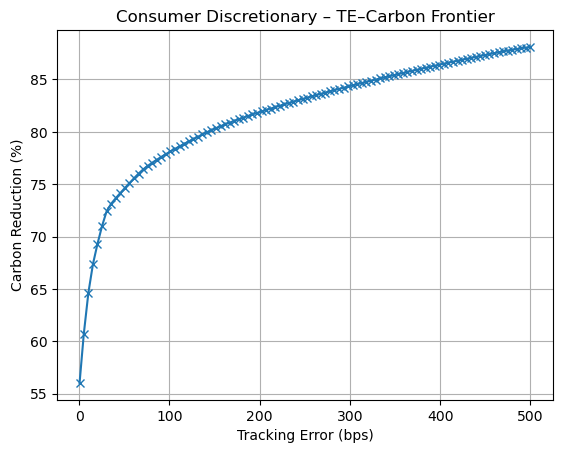

Health Care
(63, 63)
Matrix rank: 25 / 63 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-1.38829280e-03 -5.46672100e-17 -8.45548585e-18 -8.20265687e-18
 -7.52522114e-18]
Low-variance variables: Index([], dtype='object')
ASSERTION ERROR FOR HEALTH CARE SECTOR: not PSD (min eig: -0.001388292797169894)


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


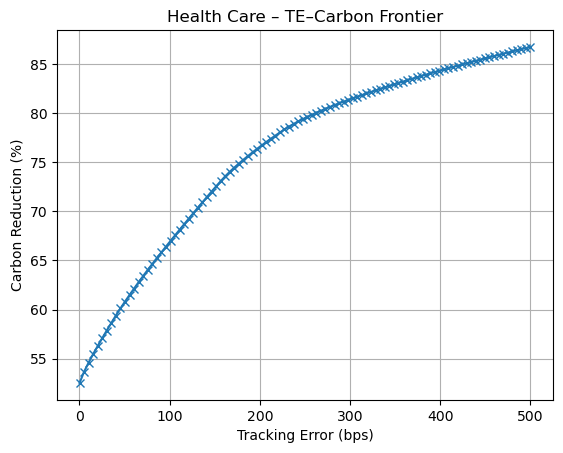

Utilities
(30, 30)
Matrix rank: 25 / 30 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-2.37397860e-03 -2.50254791e-18 -1.39874698e-18 -6.74120500e-19
  8.15916939e-19]
Low-variance variables: Index([], dtype='object')
ASSERTION ERROR FOR UTILITIES SECTOR: not PSD (min eig: -0.0023739786032029495)


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


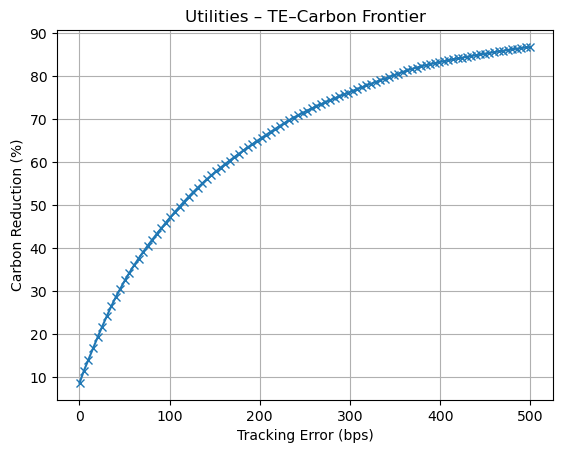

Information Technology
(63, 63)
Matrix rank: 24 / 63 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-3.35609013e-17 -1.94620167e-17 -1.18015318e-17 -1.08463686e-17
 -9.39248343e-18]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


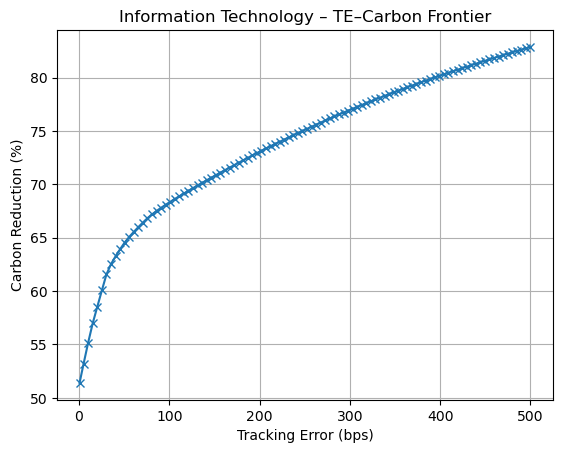

Real Estate
(32, 32)
Matrix rank: 24 / 32 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-3.18484400e-18 -2.06565896e-18 -6.75372726e-19 -4.53074382e-19
 -3.16776125e-20]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


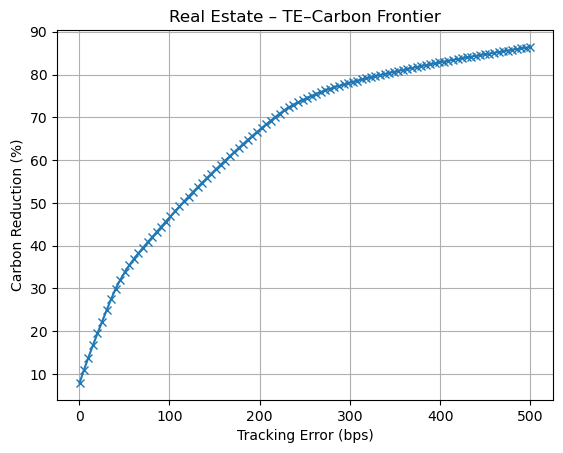

Materials
(29, 29)
Matrix rank: 24 / 29 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-1.19004747e-18 -9.57496612e-19  6.30084780e-19  2.20100786e-18
  2.62718697e-18]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


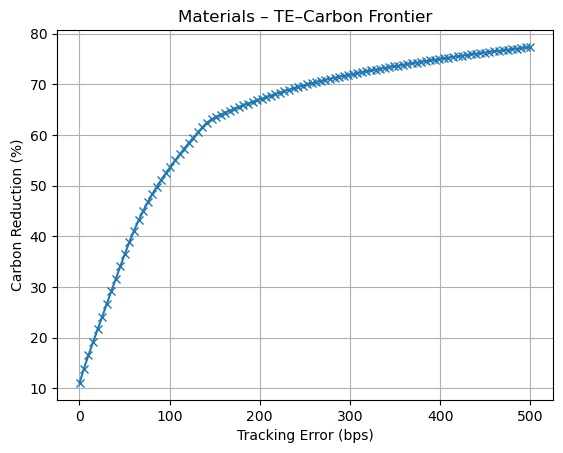

Industrials
(74, 74)
Matrix rank: 24 / 74 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-5.35505983e-17 -9.08954702e-18 -8.08081578e-18 -7.68160449e-18
 -6.14615246e-18]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


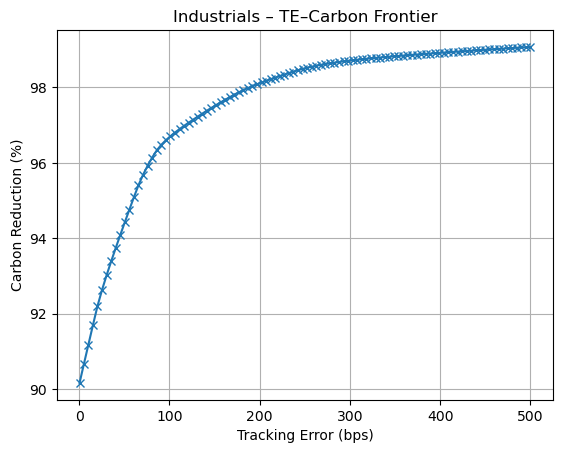

Financials
(75, 75)
Matrix rank: 24 / 75 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-7.86843065e-17 -1.19358127e-17 -9.74326203e-18 -8.63678158e-18
 -7.67307090e-18]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


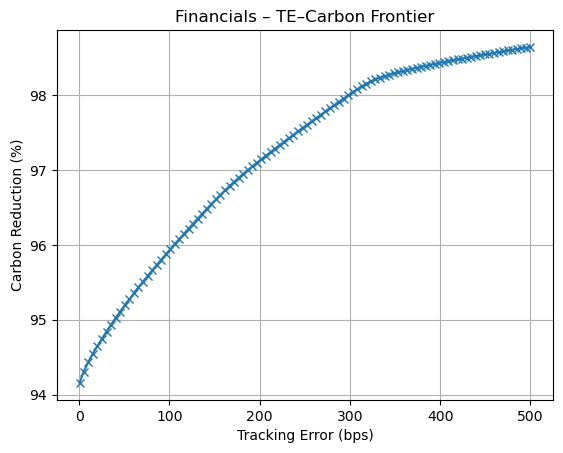

Energy
(23, 23)
Matrix rank: 23 / 23 features
Smallest eigenvalues: [2.22779853e-05 2.96038298e-05 7.50102466e-05 9.13723114e-05
 2.36027369e-04]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


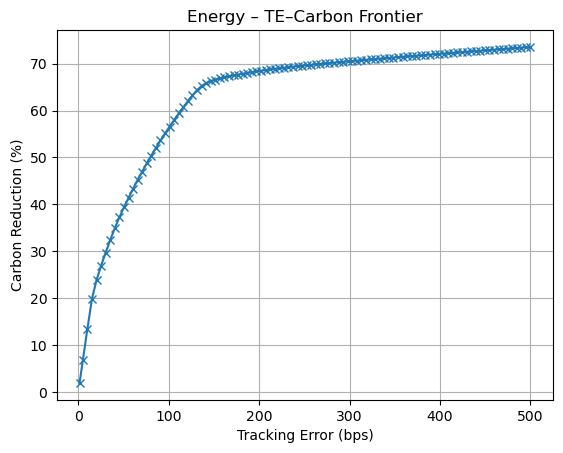

Communication Services
(22, 22)
Matrix rank: 22 / 22 features
Smallest eigenvalues: [4.89644988e-05 6.95918023e-05 1.58415097e-04 3.24683083e-04
 4.69212954e-04]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


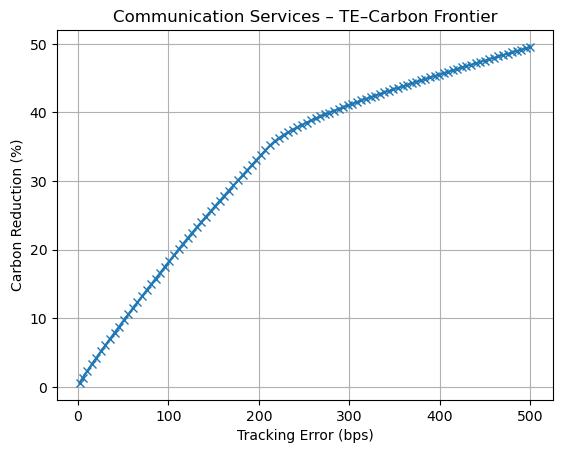

Consumer Staples
(37, 37)
Matrix rank: 24 / 37 features
⚠️ Linear dependency detected
Smallest eigenvalues: [-5.08908336e-18 -3.39693549e-18 -2.48835258e-18 -1.21776274e-18
 -1.06700329e-18]
Low-variance variables: Index([], dtype='object')


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


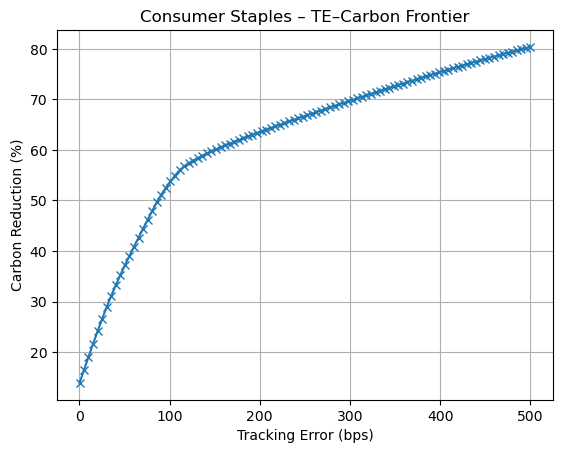

In [9]:
import cvxpy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cvxpy.atoms.affine.wraps import psd_wrap
data = pd.read_excel("dataset_comp_1222.xlsx")

def nearest_psd(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    eigvals[eigvals < 0] = 0  # clip negative eigenvalues
    return eigvecs @ np.diag(eigvals) @ eigvecs.T

for sector_name in data['GICS Sector'].unique():
    print(sector_name)
    sector = data.loc[data['GICS Sector'] == sector_name]

    # Benchmark weights (should sum to 1)
    w_b_sector = sector[['weight_in_sector']]
    assert np.isclose(w_b_sector.sum().values[0], 1.0), f"{sector_name}: weights don't sum to 1"

    # Carbon intensities
    c_sector = sector[['Carbon Intensity']]
    assert c_sector.isna().sum().values[0] == 0, f"{sector_name}: carbon data has NaNs"

    # Covariance matrix
    cov_sector = pd.read_excel("sector_cov_matrices_comp_1222.xlsx", sheet_name=sector_name)
    sigma_sector_df = cov_sector.set_index('Unnamed: 0')
    sigma_sector_df.index.name = None

    # Ensure symmetry and PSD
    assert sigma_sector_df.equals(sigma_sector_df.T), f"{sector_name}: not symmetric"
    Sigma_sector = sigma_sector_df.values
    assert np.allclose(Sigma_sector, Sigma_sector.T), f"{sector_name}: not symmetric (numerically)"
    eigvals = np.linalg.eigvalsh(Sigma_sector)
    print(Sigma_sector.shape)
    import numpy as np

    rank = np.linalg.matrix_rank(Sigma_sector)
    num_features = Sigma_sector.shape[1]
    print(f"Matrix rank: {rank} / {num_features} features")

    if rank < num_features:
        print("⚠️ Linear dependency detected")

    # Convert covariance matrix to correlation matrix
    stddev = np.sqrt(np.diag(Sigma_sector))
    corr_matrix = Sigma_sector / np.outer(stddev, stddev)
    
    # Handle numerical artifacts on the diagonal (force to 1)
    np.fill_diagonal(corr_matrix, 1.0)

    # Check for high correlations
    high_corr = (np.abs(corr_matrix) > 0.999) & (~np.eye(corr_matrix.shape[0], dtype=bool))
    if np.any(high_corr):
        print("⚠️ Highly correlated variable pairs (based on covariance):")
        rows, cols = np.where(high_corr)
        for r, c in zip(rows, cols):
            print(f"  Variable {r} and {c} — Corr: {corr_matrix[r, c]:.4f}")
    print("Smallest eigenvalues:", np.sort(eigvals)[:5])

    variances = np.diag(Sigma_sector)
    low_var_idx = np.where(variances < 1e-6)[0]
    print("Low-variance variables:", sigma_sector_df.columns[low_var_idx])


    if not np.all(eigvals >= -1e-6):
        print(f"ASSERTION ERROR FOR {sector_name.upper()} SECTOR: not PSD (min eig: {eigvals.min()})")
        # Regularization (ridge)
        epsilon = 1e-6  # small regularization parameter
        #Sigma_sector = Sigma_sector + epsilon * np.eye(Sigma_sector.shape[0])

    Sigma_sector = nearest_psd(Sigma_sector)

    # Inputs
    N = len(w_b_sector)
    w_b_vec = w_b_sector.values.flatten()
    c_vec = c_sector.values.flatten()

    # TE caps and results
    te_caps_annual = np.linspace(0.0, 0.05, 100)  # up to 10% TE
    tracking_errors = []
    carbon_reductions = []

    for te_annual in te_caps_annual:
        # Convert to monthly variance
        te_cap_var_monthly = (te_annual / np.sqrt(12)) ** 2

        # Optimization
        w = cp.Variable(N)
        tracking_error = cp.quad_form(w - w_b_vec, psd_wrap(Sigma_sector))
        constraints = [
            tracking_error <= te_cap_var_monthly,
            cp.sum(w) == 1,
            w >= 0,
        ]
        objective = cp.Minimize(cp.sum(cp.multiply(w, c_vec)))
        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.ECOS, verbose=False)

        w_opt = w.value
        if w_opt is not None:
            # Ex-post tracking error (annualized)
            diff = w_opt - w_b_vec
            te_real = np.sqrt(diff.T @ Sigma_sector @ diff) * np.sqrt(12)
            tracking_errors.append(te_real * 10000)  # in bps

            # Carbon reduction
            carbon_b = w_b_vec @ c_vec
            carbon_opt = w_opt @ c_vec
            reduction_pct = (carbon_b - carbon_opt) / carbon_b * 100
            carbon_reductions.append(reduction_pct)

    # Plot once per sector
    plt.plot(tracking_errors, carbon_reductions, 'x-', label=sector_name)
    plt.xlabel('Tracking Error (bps)')
    plt.ylabel('Carbon Reduction (%)')
    plt.title(f'{sector_name} – TE–Carbon Frontier')
    plt.grid(True)
    plt.show()


In [5]:
!pip install ecos


  Using cached ecos-2.0.14.tar.gz (142 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ecos: filename=ecos-2.0.14-cp312-cp312-macosx_11_0_arm64.whl size=72521 sha256=61e4dd89f36129eb2abef5934d1c9cac7e6a496bae60917fedb6678603485bc3
  Stored in directory: /Users/rebeccadifrancesco/Library/Caches/pip/wheels/b8/d9/1e/77a592ed2465d4dde07f30f787f9d43834c0fd7a1467371694
Successfully built ecos


# one single plot with the 11 te-carbon frontiers, permutation?, heatmap 